# BoostFL_IoT : Boosting-based Federated Learning for IoT Intrusion Detection

## 1. Imports and environment

In [1]:
import os
import math
import copy
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset

import flwr as fl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
)

try:
    from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE
    HAVE_IMBLEARN = True
except Exception:
    HAVE_IMBLEARN = False
    print("[warn] imbalanced-learn not installed - oversampling will be skipped.")

warnings.filterwarnings("ignore")

DEVICE = device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch {torch.__version__}")

GPU_PER_CLIENT = 0.5 if torch.cuda.is_available() else 0.0
CPUS_PER_CLIENT = max(1, (os.cpu_count() or 2) // 2)

Using device: cuda
PyTorch 2.5.1+cu121


## 2. Configuration

In [2]:
RUN_SEEDS = [43, 44, 45]

NUM_CLIENTS    = 5
NUM_PARTITIONS = 5
NUM_ROUNDS     = 30
BATCH_SIZE     = 32
IID            = False
NUM_SHARDS     = 100
MIN_SHARDS     = 1
MAX_SHARDS     = 30

EPOCHS               = 5
LEARNING_RATE        = 0.001
learning_rate_server = 1.0
EPSILON              = 1e-8
MAX_ALPHA            = 10.0
MIN_ALPHA            = 0.1

NORMAL_CLASS_NAME = "normal"

DATA_PATH = "../../data/ToN-IoT_extracted.csv"

print("Configuration loaded.")
print(f"  seeds        = {RUN_SEEDS}")
print(f"  clients (K)  = {NUM_CLIENTS}")
print(f"  rounds  (T)  = {NUM_ROUNDS}")

Configuration loaded.
  seeds        = [43, 44, 45]
  clients (K)  = 5
  rounds  (T)  = 30


In [3]:
def set_seed(seed: int):
    """Seed every source of randomness so a run is reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
def detection_metrics(y_true, y_pred, class_names, normal_name=NORMAL_CLASS_NAME):
    """Binary attack-vs-normal DR and FAR from multiclass predictions.

    positive = attack (any non-normal class); negative = normal (benign).
      DR  = TP / (TP + FN)   detection rate  (attack recall)
      FAR = FP / (FP + TN)   false alarm rate (false positive rate)
    Returns (dr, far); either is nan if its denominator is zero.
    """
    names = [str(c) for c in class_names]
    normal_id = names.index(normal_name) if normal_name in names else -1

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_attack = y_true != normal_id
    pred_attack = y_pred != normal_id

    TP = int(np.sum(true_attack & pred_attack))
    FN = int(np.sum(true_attack & ~pred_attack))
    FP = int(np.sum(~true_attack & pred_attack))
    TN = int(np.sum(~true_attack & ~pred_attack))

    dr  = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
    far = FP / (FP + TN) if (FP + TN) > 0 else float("nan")
    return dr, far

## 3. Data pipeline

In [5]:
def load_toniot_extracted_dataset(
    file_path=DATA_PATH,
    seed=42,
    test_size=0.3,
    target_column="type",
    safe_min=2000,
    target_ratio=0.40,
    ros_extreme_k=2,
    smote_k_neighbors=5,
):
    """Load and preprocess the ToN-IoT extracted dataset.

    Returns train/test tensors, the class names, and the number of classes.
    The pipeline (split, scaling, oversampling) is fully controlled by `seed`.
    """
    print("Loading ToN-IoT extracted dataset...")

    df = pd.read_csv(file_path)
    if target_column not in df.columns:
        raise ValueError(f"Target column '{target_column}' not found. Available columns: {list(df.columns)}")
    df["label"] = df[target_column]

    y_init = df["label"].copy()
    drop_cols = ["label", target_column]
    cols_to_drop_extra = [
        "subcategory ", "subcategory", "attack", "pkSeqID",
        "saddr", "daddr", "soui", "doui", "sco", "dco",
        "smac", "dmac", "Label",
    ]
    drop_cols += cols_to_drop_extra
    X_init = df.drop(columns=drop_cols, errors="ignore").copy()

    non_numeric_cols = X_init.select_dtypes(exclude=[np.number]).columns.tolist()
    for col in non_numeric_cols:
        le = LabelEncoder()
        X_init[col] = le.fit_transform(X_init[col].astype(str))

    X_init = X_init.apply(lambda _col: _col.map(lambda v: str(v).strip() if isinstance(v, str) else v))
    X_init = X_init.apply(pd.to_numeric, errors="coerce")
    X_init = X_init.replace([np.inf, -np.inf], np.nan).fillna(0)

    y_init = y_init.astype(str).str.strip().replace(["nan", "None", ""], np.nan)
    df_clean = pd.concat([X_init, y_init.rename("label")], axis=1).dropna(subset=["label"])
    X_init = df_clean.drop(columns=["label"])
    y_init = df_clean["label"]

    X_init_array = X_init.values.astype(np.float64)
    y_init_array = y_init.values

    temp_label_encoder = LabelEncoder()
    y_encoded_temp = temp_label_encoder.fit_transform(y_init_array)

    X_train, X_test, y_train, y_test = train_test_split(
        X_init_array, y_encoded_temp, test_size=test_size,
        random_state=seed, stratify=y_encoded_temp,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    y_train_counts = pd.Series(y_train).value_counts().sort_index()
    if HAVE_IMBLEARN:

        sorted_by_count = y_train_counts.sort_values(ascending=True)
        extreme_candidates = list(sorted_by_count.index[:ros_extreme_k])
        ros_targets = {}
        for cid in extreme_candidates:
            current = int(y_train_counts.get(cid, 0))
            if 0 < current < safe_min:
                ros_targets[cid] = safe_min
        if ros_targets:
            ros = RandomOverSampler(sampling_strategy=ros_targets, random_state=seed)
            X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)
        else:
            X_train_ros, y_train_ros = X_train_scaled, y_train

        y_ros_counts = pd.Series(y_train_ros).value_counts().sort_index()
        target = int(target_ratio * int(y_ros_counts.max()))
        smote_strategy = {cid: target for cid, cnt in y_ros_counts.items() if cnt < target}
        if smote_strategy:
            min_class_size = int(y_ros_counts.min())
            k_eff = min(smote_k_neighbors, max(1, min_class_size - 1))
            if k_eff < 2:
                X_train_bal, y_train_bal = X_train_ros, y_train_ros
            else:
                bsmote = BorderlineSMOTE(sampling_strategy=smote_strategy,
                                         random_state=seed, k_neighbors=k_eff)
                X_train_bal, y_train_bal = bsmote.fit_resample(X_train_ros, y_train_ros)
        else:
            X_train_bal, y_train_bal = X_train_ros, y_train_ros
    else:
        X_train_bal, y_train_bal = X_train_scaled, y_train

    X_train_tensor = torch.FloatTensor(X_train_bal)
    y_train_tensor = torch.LongTensor(y_train_bal)
    X_test_tensor  = torch.FloatTensor(X_test_scaled)
    y_test_tensor  = torch.LongTensor(y_test)

    class_names = temp_label_encoder.classes_
    num_classes = len(class_names)

    print(f"  classes  : {list(class_names)}")
    print(f"  #features={X_train_tensor.shape[1]}  #train={len(X_train_tensor)}  #test={len(X_test_tensor)}")
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, class_names, num_classes

## 4. Non-IID partitioning

In [6]:
def partition_dataset_iid(dataset, num_partitions, num_classes):
    """Balanced IID partition: each partition receives a proportional slice of every class."""
    num_samples = len(dataset)
    labels = np.array([int(dataset[i][1]) for i in range(num_samples)])
    indices_by_class = [[] for _ in range(num_classes)]
    for idx, label in enumerate(labels):
        indices_by_class[label].append(idx)
    partitions = [[] for _ in range(num_partitions)]
    for c in range(num_classes):
        indices = indices_by_class[c]
        np.random.shuffle(indices)
        per = len(indices) // num_partitions
        rem = len(indices) % num_partitions
        start = 0
        for p in range(num_partitions):
            extra = 1 if p < rem else 0
            end = start + per + extra
            partitions[p].extend(indices[start:end])
            start = end
    for p in range(num_partitions):
        np.random.shuffle(partitions[p])
    return partitions

def partition_dataset_shards_noniid(dataset, num_clients, num_shards=100,
                                    min_shards=1, max_shards=30, seed=42, verbose=True):
    """Shard-based Non-IID partition (label-sorted shards distributed unevenly across clients)."""
    rng = np.random.default_rng(seed)
    n = len(dataset)
    labels = np.array([int(dataset[i][1]) for i in range(n)])
    sorted_indices = np.argsort(labels)

    shard_sizes = np.full(num_shards, n // num_shards, dtype=int)
    shard_sizes[: (n % num_shards)] += 1
    shards = []
    start = 0
    for sz in shard_sizes:
        shards.append(sorted_indices[start:start + sz].tolist())
        start += sz

    shards_per_client = np.full(num_clients, min_shards, dtype=int)
    remaining = num_shards - shards_per_client.sum()
    if remaining < 0:
        raise ValueError("min_shards is too large for num_shards and num_clients.")
    while remaining > 0:
        c = rng.integers(0, num_clients)
        if shards_per_client[c] < max_shards:
            shards_per_client[c] += 1
            remaining -= 1

    shard_ids = rng.permutation(num_shards).tolist()
    partitions = [[] for _ in range(num_clients)]
    ptr = 0
    for c in range(num_clients):
        take = int(shards_per_client[c])
        chosen = shard_ids[ptr:ptr + take]
        ptr += take
        for sid in chosen:
            partitions[c].extend(shards[sid])
    for c in range(num_clients):
        rng.shuffle(partitions[c])

    if verbose:
        print(f"\nNon-IID (shards) stats: num_shards={num_shards}, shards/client in [{min_shards},{max_shards}]")
        for c in range(num_clients):
            part_labels = labels[partitions[c]]
            uniq, cnt = np.unique(part_labels, return_counts=True)
            dist = {int(u): int(k) for u, k in zip(uniq, cnt)}
            print(f"Client {c}: {len(partitions[c])} samples | #classes={len(dist)} | dist={dist}")
    return partitions

## 5. Model and global ensemble

In [7]:
class Model(nn.Module):
    """Weak-learner MLP: Dense+ReLU x3 -> Dense (logits)."""
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 50)
        self.fc4 = nn.Linear(50, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

class BoostFLEnsemble:
    """Ensemble that stores and uses all weak learners."""
    def __init__(self, f0, input_dim, num_classes, device):
        self.f0 = f0.to(device)
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.device = device
        self.base_learners = []
        self.alphas = []

    def add_learner(self, model_params, alpha):
        new_learner = Model(self.input_dim, self.num_classes).to(self.device)
        state_dict = new_learner.state_dict()
        new_state_dict = {
            k: torch.tensor(v).to(self.device) if isinstance(v, np.ndarray) else v.to(self.device)
            for k, v in zip(state_dict.keys(), model_params)
        }
        new_learner.load_state_dict(new_state_dict)
        new_learner.eval()
        self.base_learners.append(new_learner)
        self.alphas.append(alpha)

    def predict(self, x):
        with torch.no_grad():
            batch_size = x.size(0)
            out = self.f0.unsqueeze(0).expand(batch_size, -1).clone()
            if self.base_learners and self.alphas:
                total_alpha = sum(self.alphas)
                if total_alpha > EPSILON:
                    weighted_sum = torch.zeros_like(out)
                    for m, alpha in zip(self.base_learners, self.alphas):
                        m.eval()
                        weighted_sum += (alpha / total_alpha) * m(x)
                    out = out + weighted_sum
            return out

    def predict_proba(self, x):
        return torch.softmax(self.predict(x), dim=1)

    def get_ensemble_info(self):
        return {
            "num_learners": len(self.base_learners),
            "alphas": self.alphas,
            "total_alpha": sum(self.alphas) if self.alphas else 0,
        }

class ClientEnsemble:
    """Client-side view of the current ensemble F_{t-1}."""
    def __init__(self, base_learners, alphas, f0):
        self.base_learners = base_learners
        self.alphas = alphas
        self.f0 = f0

    def predict(self, x):
        with torch.no_grad():
            batch_size = x.size(0)
            out = self.f0.unsqueeze(0).expand(batch_size, -1).clone()
            if self.base_learners and self.alphas:
                total_alpha = sum(self.alphas)
                if total_alpha > EPSILON:
                    weighted_sum = torch.zeros_like(out)
                    for m, alpha in zip(self.base_learners, self.alphas):
                        m.eval()
                        weighted_sum += (alpha / total_alpha) * m(x)
                    out = out + weighted_sum
            return out

    def predict_proba(self, x):
        return torch.softmax(self.predict(x), dim=1)

class ResidualLoss(nn.Module):
    """Stabilized loss for training on probability residuals."""
    def __init__(self):
        super().__init__()

    def forward(self, predictions, residuals):
        return F.smooth_l1_loss(predictions, residuals)

## 6. Flower client

In [8]:
def make_client_fn(train_dataset, train_partitions, input_dim, num_classes, device):
    """Return a client_fn closing over this seed's data / partitions / dims."""
    def client_fn(cid: str):
        cid_int = int(cid)
        partition_indices = train_partitions[cid_int]
        client_dataset = Subset(train_dataset, partition_indices)
        train_dataloader = DataLoader(client_dataset, batch_size=BATCH_SIZE, shuffle=True)

        f_t = Model(input_dim, num_classes).to(device)
        f0 = torch.randn(num_classes, device=device) * 0.01
        residual_loss_fn = ResidualLoss()

        learners, alphas = [], []

        class FlowerClient(fl.client.NumPyClient):
            def __init__(self):
                self.learners = learners
                self.alphas = alphas
                self.f0 = f0
                self.f_t = f_t
                self.device = device
                self.train_dataset = client_dataset
                self.residual_loss_fn = residual_loss_fn

            def get_parameters(self, config=None):
                return [val.cpu().numpy() for val in self.f_t.state_dict().values()]

            def fit(self, parameters, config):
                state_dict = self.f_t.state_dict()
                new_state_dict = {k: torch.tensor(v).to(self.device)
                                  for k, v in zip(state_dict.keys(), parameters)}
                self.f_t.load_state_dict(new_state_dict)
                self.f_t.train()

                optimizer = optim.Adam(self.f_t.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
                ensemble = ClientEnsemble(self.learners, self.alphas, self.f0)

                total_residual_loss = 0.0
                for epoch in range(EPOCHS):
                    epoch_residual_loss = 0.0
                    num_batches = 0
                    for x_batch, y_batch in train_dataloader:
                        x_batch = x_batch.to(self.device)
                        y_batch = y_batch.to(self.device)

                        with torch.no_grad():
                            ensemble_logits = ensemble.predict(x_batch)
                            ensemble_probs = torch.softmax(ensemble_logits, dim=1)
                            y_one_hot = torch.zeros(y_batch.size(0), num_classes, device=self.device)
                            y_one_hot.scatter_(1, y_batch.unsqueeze(1), 1)
                            residuals = y_one_hot - ensemble_probs

                        optimizer.zero_grad()
                        weak_learner_logits = self.f_t(x_batch)
                        loss = self.residual_loss_fn(weak_learner_logits, residuals)
                        loss.backward()
                        optimizer.step()

                        epoch_residual_loss += loss.item()
                        num_batches += 1

                    avg_epoch_loss = epoch_residual_loss / num_batches if num_batches > 0 else 0
                    total_residual_loss += epoch_residual_loss

                avg_residual_loss = (total_residual_loss / (EPOCHS * len(train_dataloader))
                                     if len(train_dataloader) > 0 else 1.0)
                avg_residual_loss = max(avg_residual_loss, EPSILON)
                avg_residual_loss = min(avg_residual_loss, 10.0)

                alpha_t = 1.0 / (1.0 + avg_residual_loss)
                alpha_t = max(MIN_ALPHA, min(MAX_ALPHA, alpha_t))

                new_learner = Model(input_dim, num_classes).to(device)
                new_learner.load_state_dict(self.f_t.state_dict())
                self.learners.append(new_learner)
                self.alphas.append(alpha_t)

                global_params = [torch.tensor(p).to(self.device) for p in parameters]
                local_params = list(self.f_t.state_dict().values())
                grad_divergence = sum((lp - gp).norm().item()
                                      for lp, gp in zip(local_params, global_params))

                return ([val.cpu().numpy() for val in self.f_t.state_dict().values()],
                        len(self.train_dataset),
                        {"grad_divergence": grad_divergence,
                         "residual_loss": avg_residual_loss, "alpha": alpha_t})

            def evaluate(self, parameters, config):
                return 0.0, len(self.train_dataset), {"loss": 0.0}

        return FlowerClient().to_client()
    return client_fn

## 7. Boosting strategy (server)

In [9]:
def make_boosting_strategy(test_dataset, input_dim, num_classes, class_names, device, history):
    """Build a BoostingStrategy that records per-round metrics into `history`."""

    class BoostingStrategy(fl.server.strategy.FedAvg):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.current_global_params = None
            self.round_count = 0
            self.input_dim = input_dim
            self.num_classes = num_classes
            self.class_names = class_names
            self.device = device
            self.history = history

            self.global_f0 = torch.randn(num_classes, device=device) * 0.01
            self.global_ensemble = BoostFLEnsemble(self.global_f0, input_dim, num_classes, device)

            self.test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)
            self.classification_loss_fn = nn.CrossEntropyLoss()

            self.global_learners_history = []
            self.global_alphas_history = []

        def initialize_parameters(self, client_manager):
            initial_model = Model(self.input_dim, self.num_classes).to(self.device)
            initial_params = [val.cpu().numpy() for val in initial_model.state_dict().values()]
            self.current_global_params = fl.common.ndarrays_to_parameters(initial_params)
            return self.current_global_params

        def evaluate_ensemble(self):
            y_true, y_pred = [], []
            total_loss, total_samples = 0.0, 0
            with torch.no_grad():
                for x_batch, y_batch in self.test_dataloader:
                    x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                    ensemble_logits = self.global_ensemble.predict(x_batch)
                    loss = self.classification_loss_fn(ensemble_logits, y_batch)
                    total_loss += loss.item() * y_batch.size(0)
                    total_samples += y_batch.size(0)
                    _, preds = torch.max(ensemble_logits, 1)
                    y_true.extend(y_batch.cpu().numpy())
                    y_pred.extend(preds.cpu().numpy())

            dr, far = detection_metrics(y_true, y_pred, self.class_names)
            return {
                "loss":      total_loss / total_samples if total_samples > 0 else 0.0,
                "accuracy":  accuracy_score(y_true, y_pred) if y_true else 0.0,
                "precision": precision_score(y_true, y_pred, average="macro", zero_division=0) if y_true else 0.0,
                "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0) if y_true else 0.0,
                "f1_score":  f1_score(y_true, y_pred, average="macro", zero_division=0) if y_true else 0.0,
                "dr":        dr,
                "far":       far,
            }

        def aggregate_fit(self, rnd, results, failures):
            self.round_count = rnd
            if not results:
                return self.current_global_params, {}

            if self.current_global_params is None:
                initial_model = Model(self.input_dim, self.num_classes).to(self.device)
                initial_params = [val.cpu().numpy() for val in initial_model.state_dict().values()]
                self.current_global_params = fl.common.ndarrays_to_parameters(initial_params)

            old_global_params = fl.common.parameters_to_ndarrays(self.current_global_params)
            weighted_updates = [np.zeros_like(p) for p in old_global_params]
            sum_alpha = 0.0
            num_examples_total = 0
            residual_losses, alphas, grad_divergences, valid_results = [], [], [], []

            for client_res in results:
                try:
                    if isinstance(client_res, tuple):
                        if len(client_res) == 3:
                            parameters, num_examples, metrics = client_res
                        elif len(client_res) == 2:
                            _, fit_res = client_res
                            parameters = fit_res.parameters
                            num_examples = fit_res.num_examples
                            metrics = fit_res.metrics
                        else:
                            continue
                    else:
                        parameters = client_res.parameters
                        num_examples = getattr(client_res, "num_examples", 0)
                        metrics = getattr(client_res, "metrics", {})

                    if not isinstance(metrics, dict) and hasattr(metrics, "metrics"):
                        metrics = metrics.metrics

                    alpha = float(metrics.get("alpha", 1.0))
                    if math.isnan(alpha) or math.isinf(alpha) or alpha <= 0:
                        alpha = 1.0
                    alpha = max(MIN_ALPHA, min(MAX_ALPHA, alpha))

                    if "grad_divergence" in metrics:
                        grad_div = float(metrics["grad_divergence"])
                        if not (math.isnan(grad_div) or math.isinf(grad_div)):
                            grad_divergences.append(grad_div)

                    local_params = fl.common.parameters_to_ndarrays(parameters)
                    if len(local_params) != len(old_global_params):
                        continue
                    valid_results.append((local_params, alpha, num_examples, metrics))
                except Exception as e:
                    print(f"Error processing client result: {e}")
                    continue

            if not valid_results:
                return self.current_global_params, {}

            for local_params, alpha, num_examples, metrics in valid_results:
                param_diff = [lp - gp for lp, gp in zip(local_params, old_global_params)]
                for i in range(len(weighted_updates)):
                    weighted_updates[i] += alpha * param_diff[i]
                sum_alpha += alpha
                num_examples_total += num_examples
                if "residual_loss" in metrics:
                    lv = float(metrics["residual_loss"])
                    if not (math.isnan(lv) or math.isinf(lv)):
                        residual_losses.append(lv)
                alphas.append(alpha)

            if sum_alpha > EPSILON:
                for i in range(len(weighted_updates)):
                    weighted_updates[i] = (weighted_updates[i] / sum_alpha) * learning_rate_server
            else:
                weighted_updates = [np.zeros_like(p) for p in old_global_params]

            new_global_params = [gp + weighted_updates[i] for i, gp in enumerate(old_global_params)]
            self.current_global_params = fl.common.ndarrays_to_parameters(new_global_params)

            mean_alpha = np.mean(alphas) if alphas else 1.0
            self.global_ensemble.add_learner(new_global_params, mean_alpha)
            self.global_learners_history.append(new_global_params)
            self.global_alphas_history.append(mean_alpha)

            test_metrics = self.evaluate_ensemble()

            self.history["round"].append(rnd)
            for key in ["accuracy", "precision", "recall", "f1_score", "dr", "far"]:
                self.history[key].append(test_metrics[key])

            return self.current_global_params, {
                "num_examples": num_examples_total,
                "residual_loss": np.mean(residual_losses) if residual_losses else 0.0,
                "alpha": mean_alpha,
                "grad_divergence": np.mean(grad_divergences) if grad_divergences else 0.0,
                "ensemble_size": self.global_ensemble.get_ensemble_info()["num_learners"],
                **test_metrics
            }

        def aggregate_evaluate(self, rnd, results, failures):
            return 0.0, {}

    return BoostingStrategy(
        fraction_fit=1.0,
        min_fit_clients=NUM_CLIENTS,
        min_available_clients=NUM_CLIENTS,
    )

## 8. Single-seed training run

In [10]:
def run_boostfl_once(seed, verbose=True):
    """Full BoostFL pipeline for a single seed. Returns (history, final, class_names)."""
    set_seed(seed)

    X_tr, y_tr, X_te, y_te, class_names, num_classes = load_toniot_extracted_dataset(seed=seed)
    input_dim = X_tr.shape[1]
    train_dataset = TensorDataset(X_tr, y_tr)
    test_dataset  = TensorDataset(X_te, y_te)

    if IID:
        partitions = partition_dataset_iid(train_dataset, NUM_PARTITIONS, num_classes)
    else:
        partitions = partition_dataset_shards_noniid(
            train_dataset, NUM_PARTITIONS, NUM_SHARDS, MIN_SHARDS, MAX_SHARDS, seed, verbose=verbose)

    history = {"round": [], "accuracy": [], "precision": [], "recall": [],
               "f1_score": [], "dr": [], "far": []}

    client_fn = make_client_fn(train_dataset, partitions, input_dim, num_classes, device)
    strategy  = make_boosting_strategy(test_dataset, input_dim, num_classes, class_names, device, history)

    fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
        strategy=strategy,
        client_resources={"num_cpus": CPUS_PER_CLIENT, "num_gpus": GPU_PER_CLIENT},
    )

    y_true, y_pred, y_prob = [], [], []
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = strategy.global_ensemble.predict(x_batch)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true); y_pred = np.array(y_pred); y_prob = np.array(y_prob)
    dr, far = detection_metrics(y_true, y_pred, class_names)
    final = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "dr":        dr,
        "far":       far,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
    }
    return history, final, class_names

## 9. Multi-seed experiment

In [11]:
all_histories = {}
all_finals = {}
class_names_ref = None

for seed in RUN_SEEDS:
    print("=" * 78)
    print(f"RUN - seed {seed}")
    print("=" * 78)
    history, final, class_names = run_boostfl_once(seed, verbose=True)
    all_histories[seed] = history
    all_finals[seed] = final
    class_names_ref = class_names
    print(f"\n[seed {seed}] FINAL  "
          f"Acc={final['accuracy']:.4f}  P={final['precision']:.4f}  "
          f"R={final['recall']:.4f}  F1={final['f1_score']:.4f}  "
          f"DR={final['dr']:.4f}  FAR={final['far']:.4f}\n")

print("All seeds complete.")

RUN - seed 43
Loading ToN-IoT extracted dataset...
  classes  : ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
  #features=42  #train=42420  #test=17194

Non-IID (shards) stats: num_shards=100, shards/client in [1,30]
Client 0: 8909 samples | #classes=8 | dist={0: 850, 1: 1275, 2: 848, 3: 1272, 5: 2120, 7: 848, 8: 1312, 9: 384}
Client 1: 7634 samples | #classes=9 | dist={0: 850, 2: 1132, 3: 988, 4: 848, 5: 848, 6: 1272, 7: 424, 8: 848, 9: 424}
Client 2: 12304 samples | #classes=10 | dist={0: 2075, 1: 1225, 2: 948, 3: 848, 4: 848, 5: 1432, 6: 1536, 7: 848, 8: 1272, 9: 1272}
Client 3: 5938 samples | #classes=6 | dist={1: 850, 2: 424, 5: 1272, 6: 544, 7: 1576, 9: 1272}
Client 4: 7635 samples | #classes=10 | dist={0: 425, 1: 850, 2: 848, 3: 1092, 4: 824, 5: 628, 6: 848, 7: 504, 8: 768, 9: 848}


2026-09-13 23:20:34,707	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout
2026-09-13 23:20:36,733	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 8741221172.0, 'object_store_memory': 3746237644.0, 'GPU': 1.0, 'node:172.29.221.236': 1.0, 'node:__internal_head__': 1.0, 'accelerator_type:G': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower 


[seed 43] FINAL  Acc=0.9265  P=0.8978  R=0.8624  F1=0.8718  DR=0.9975  FAR=0.0015

RUN - seed 44
Loading ToN-IoT extracted dataset...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout


  classes  : ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
  #features=42  #train=42420  #test=17194

Non-IID (shards) stats: num_shards=100, shards/client in [1,30]
Client 0: 7211 samples | #classes=10 | dist={0: 425, 1: 850, 2: 848, 3: 668, 4: 180, 5: 2120, 6: 848, 7: 424, 8: 424, 9: 424}
Client 1: 7635 samples | #classes=8 | dist={0: 1275, 2: 1272, 3: 424, 4: 644, 5: 1212, 6: 1112, 7: 1272, 8: 424}
Client 2: 8908 samples | #classes=8 | dist={1: 1700, 2: 1132, 3: 988, 4: 848, 5: 1272, 7: 928, 8: 808, 9: 1232}
Client 3: 8061 samples | #classes=8 | dist={0: 800, 1: 1325, 3: 848, 5: 848, 6: 544, 7: 728, 8: 1696, 9: 1272}
Client 4: 10605 samples | #classes=10 | dist={0: 1700, 1: 325, 2: 948, 3: 1272, 4: 848, 5: 848, 6: 1696, 7: 848, 8: 848, 9: 1272}


...


[seed 44] FINAL  Acc=0.9110  P=0.8690  R=0.9031  F1=0.8692  DR=0.9972  FAR=0.0037

RUN - seed 45
Loading ToN-IoT extracted dataset...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout


  classes  : ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
  #features=42  #train=42420  #test=17194

Non-IID (shards) stats: num_shards=100, shards/client in [1,30]
Client 0: 8061 samples | #classes=9 | dist={0: 425, 1: 1700, 2: 424, 4: 1068, 5: 1052, 6: 1272, 7: 1272, 8: 424, 9: 424}
Client 1: 6362 samples | #classes=8 | dist={0: 425, 1: 425, 2: 424, 3: 848, 4: 848, 5: 1272, 8: 464, 9: 1656}
Client 2: 10606 samples | #classes=10 | dist={0: 1275, 1: 1275, 2: 1272, 3: 1696, 4: 424, 5: 848, 6: 424, 7: 848, 8: 1696, 9: 848}
Client 3: 8483 samples | #classes=10 | dist={0: 800, 1: 475, 2: 1132, 3: 1232, 4: 180, 5: 1008, 6: 1112, 7: 848, 8: 848, 9: 848}
Client 4: 8908 samples | #classes=9 | dist={0: 1275, 1: 325, 2: 948, 3: 424, 5: 2120, 6: 1392, 7: 1232, 8: 768, 9: 424}


(ClientAppActor pid=30722) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 3x across cluster]
(ClientAppActor pid=30722)             This is a deprecated feature. It will be removed [repeated 3x across cluster]
(ClientAppActor pid=30722)             entirely in future versions of Flower. [repeated 3x across cluster]
2026-09-13 23:33:18,195	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9128792064.0, 'object_store_memory': 3912339456.0, 'accelerator_type:G': 1.0, 'node:172.29.221.236': 1.0, 'node:__internal_head__': 1.0, 'GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual


[seed 45] FINAL  Acc=0.9128  P=0.8629  R=0.8897  F1=0.8716  DR=0.9981  FAR=0.0041

All seeds complete.


## 10. Aggregated results (mean ± std over seeds)

In [12]:
metrics = ["accuracy", "precision", "recall", "f1_score", "dr", "far"]
metric_labels = {"accuracy": "Accuracy", "precision": "Precision",
                 "recall": "Recall", "f1_score": "F1 Score",
                 "dr": "Detection Rate", "far": "False Alarm Rate"}

rows = []
for seed in RUN_SEEDS:
    f = all_finals[seed]
    row = {metric_labels[m]: f[m] for m in metrics}
    row["Seed"] = seed
    rows.append(row)
per_seed_df = pd.DataFrame(rows).set_index("Seed")[[metric_labels[m] for m in metrics]]

summary = pd.DataFrame({
    "Mean": [np.nanmean([all_finals[s][m] for s in RUN_SEEDS]) for m in metrics],
    "Std":  [np.nanstd ([all_finals[s][m] for s in RUN_SEEDS]) for m in metrics],
}, index=[metric_labels[m] for m in metrics])

print("Per-seed final metrics")
print("-" * 66)
print(per_seed_df.round(4).to_string())
print()
print("Summary (mean +/- std over seeds)")
print("-" * 66)
for m in metrics:
    lbl = metric_labels[m]
    print(f"  {lbl:18s}: {summary.loc[lbl, 'Mean']:.4f} +/- {summary.loc[lbl, 'Std']:.4f}")
print()

Per-seed final metrics
------------------------------------------------------------------
      Accuracy  Precision  Recall  F1 Score  Detection Rate  False Alarm Rate
Seed                                                                         
43      0.9265     0.8978  0.8624    0.8718          0.9975            0.0015
44      0.9110     0.8690  0.9031    0.8692          0.9972            0.0037
45      0.9128     0.8629  0.8897    0.8716          0.9981            0.0041

Summary (mean +/- std over seeds)
------------------------------------------------------------------
  Accuracy          : 0.9168 +/- 0.0069
  Precision         : 0.8766 +/- 0.0152
  Recall            : 0.8850 +/- 0.0170
  F1 Score          : 0.8709 +/- 0.0012
  Detection Rate    : 0.9976 +/- 0.0004
  False Alarm Rate  : 0.0031 +/- 0.0011



In [13]:
report_df = pd.DataFrame({
    "BoostFL (mean +/- std)": [
        f"{summary.loc[metric_labels[m], 'Mean']:.4f} +/- {summary.loc[metric_labels[m], 'Std']:.4f}"
        for m in metrics
    ]
}, index=[metric_labels[m] for m in metrics])
report_df

,BoostFL (mean +/- std)
Accuracy,0.9168 +/- 0.0069
Precision,0.8766 +/- 0.0152
Recall,0.8850 +/- 0.0170
F1 Score,0.8709 +/- 0.0012
Detection Rate,0.9976 +/- 0.0004
False Alarm Rate,0.0031 +/- 0.0011


## 11. Convergence curves

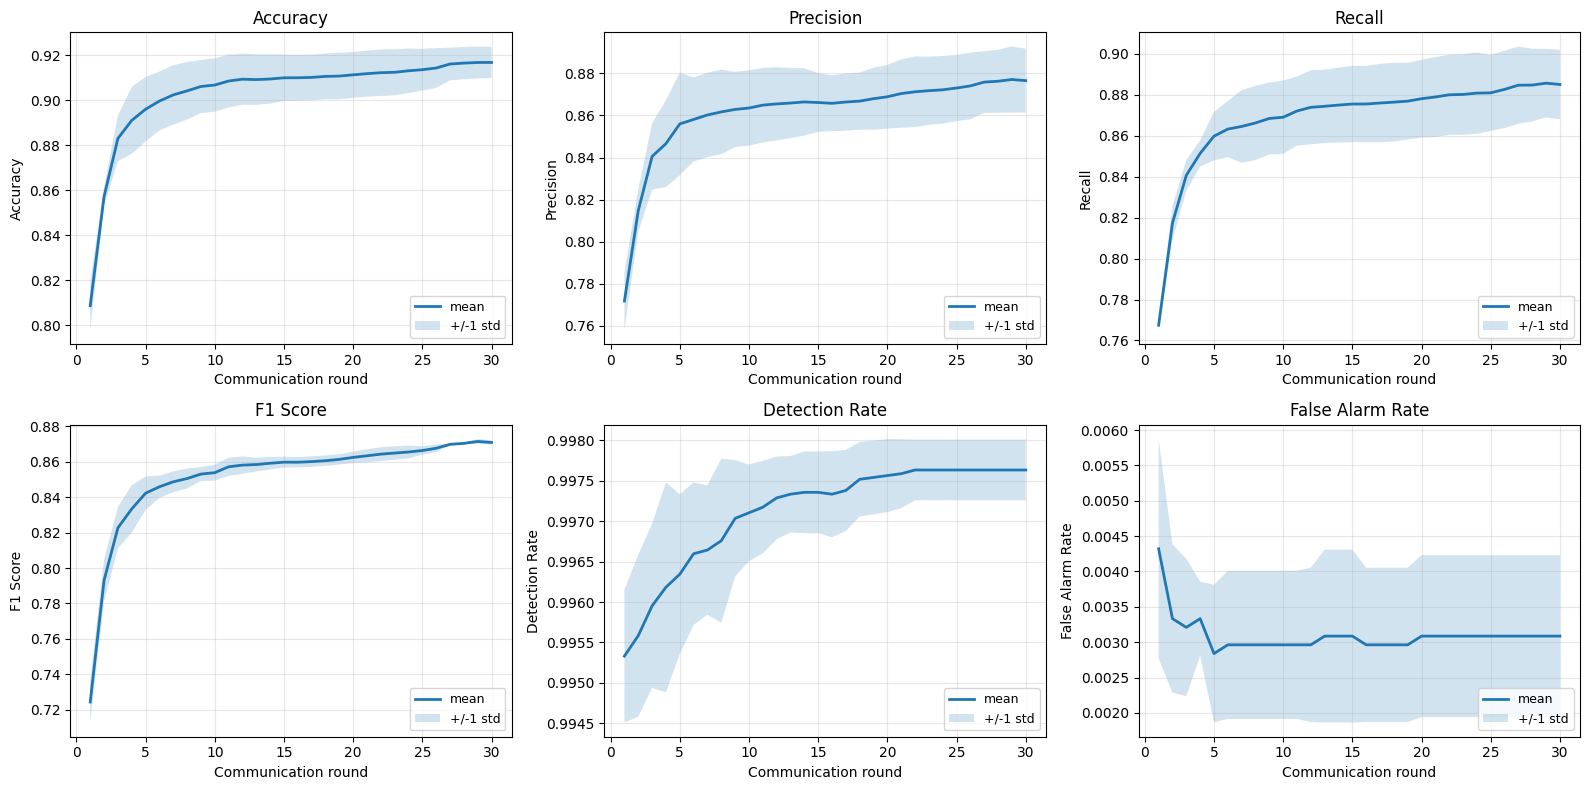

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
rounds = np.arange(1, NUM_ROUNDS + 1)

for ax, m in zip(axes.ravel(), metrics):
    stacked = np.array([all_histories[s][m] for s in RUN_SEEDS])
    mean = np.nanmean(stacked, axis=0)
    std  = np.nanstd(stacked, axis=0)
    ax.plot(rounds, mean, linewidth=2, label="mean")
    ax.fill_between(rounds, mean - std, mean + std, alpha=0.2, label="+/-1 std")
    ax.set_title(metric_labels[m])
    ax.set_xlabel("Communication round")
    ax.set_ylabel(metric_labels[m])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()

## 13. Persist results

In [16]:
per_seed_df.to_csv("boostfl_per_seed_metrics.csv")
summary.round(6).to_csv("boostfl_summary_mean_std.csv")
report_df.to_csv("boostfl_report_table.csv")
print("Saved: boostfl_per_seed_metrics.csv, boostfl_summary_mean_std.csv, boostfl_report_table.csv")

Saved: boostfl_per_seed_metrics.csv, boostfl_summary_mean_std.csv, boostfl_report_table.csv
